In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

df_train = pd.read_csv('aps_failure_training_set.csv', skiprows=20, na_values='na')
df_test  = pd.read_csv('aps_failure_test_set.csv',  skiprows=20, na_values='na')

df_train.head(5)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


# Exploratory Data Analysis

In [2]:
df_train.shape
df_train.info()
df_train.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), object(1)
memory usage: 78.3+ MB


,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,...,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,...,4.454897e+05,2.111264e+05,4.457343e+05,3.939462e+05,3.330582e+05,3.462714e+05,1.387300e+05,8.388915e+03,0.090579,0.212756
std,1.454301e+05,3.478962,7.948749e+08,4.040441e+07,161.543373,209.792592,2.047846e+04,3.420053e+04,1.503220e+05,7.617312e+05,...,1.155540e+06,5.433188e+05,1.168314e+06,1.121044e+06,1.069160e+06,1.728056e+06,4.495100e+05,4.747043e+04,4.368855,8.830641
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.340000e+02,0.000000,1.600000e+01,2.400000e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.936000e+03,1.166000e+03,2.700000e+03,3.584000e+03,5.120000e+02,1.100000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.077600e+04,0.000000,1.520000e+02,1.260000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.337960e+05,1.120860e+05,2.215180e+05,1.899880e+05,9.243200e+04,4.109800e+04,3.812000e+03,0.000000e+00,0.000000,0.000000
75%,4.866800e+04,0.000000,9.640000e+02,4.300000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.383960e+05,2.182320e+05,4.666140e+05,4.032220e+05,2.750940e+05,1.678140e+05,1.397240e+05,2.028000e+03,0.000000,0.000000
max,2.746564e+06,204.000000,2.130707e+09,8.584298e+09,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,7.793393e+07,3.775839e+07,9.715238e+07,5.743524e+07,3.160781e+07,1.195801e+08,1.926740e+07,3.810078e+06,482.000000,1146.000000


This dataset has a large amount of sensor data. At first glance many features have missing values and is comprised of numerical values with the exception of the target variable which is text. The summary shows that the features have large differences in scale and there are extreme values which means that there are likely outliers. The target values need to be binary encoded.

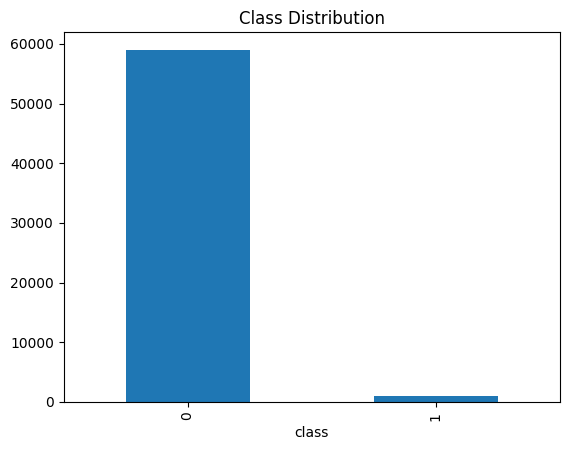

In [3]:
df_train['class'] = df_train['class'].map({'neg': 0, 'pos': 1})
df_test['class']  = df_test['class'].map({'neg': 0, 'pos': 1})

df_train['class'].value_counts()
df_train['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

The class distribution is severely imbalanced with many more negative cases than positive ones. This could affect the performance of the model so it needs to be noted and evaluated carefully.

In [4]:
missing = df_train.isnull().mean().sort_values(ascending=False)
missing.head(20)

br_000    0.821067
bq_000    0.812033
bp_000    0.795667
bo_000    0.772217
ab_000    0.772150
cr_000    0.772150
bn_000    0.733483
bm_000    0.659150
bl_000    0.454617
bk_000    0.383900
ad_000    0.247683
cg_000    0.247683
ch_000    0.247683
cf_000    0.247683
co_000    0.247683
cx_000    0.230133
cz_000    0.230133
cy_000    0.230133
dc_000    0.230133
db_000    0.230133
dtype: float64

From the initial visual data inspection it looked like the set features might have a high number of missing values. Some of these will likely need to be removed.

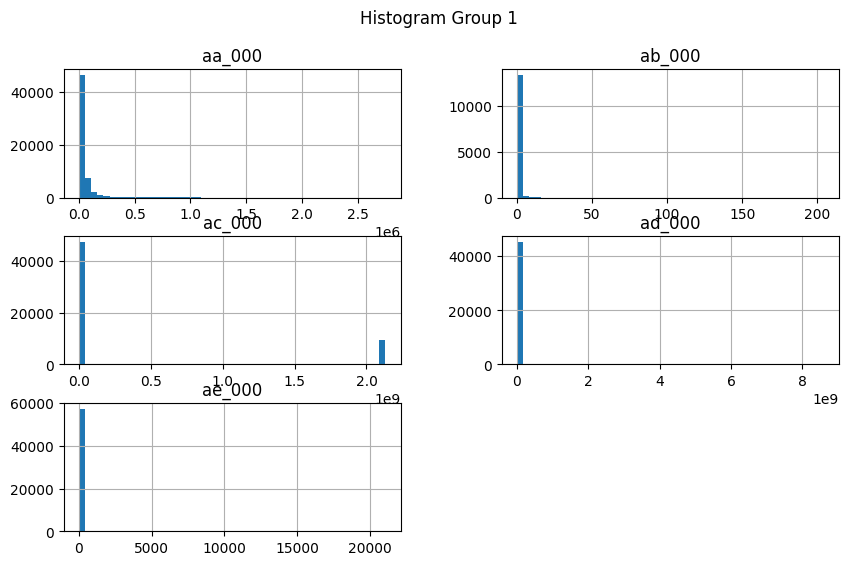

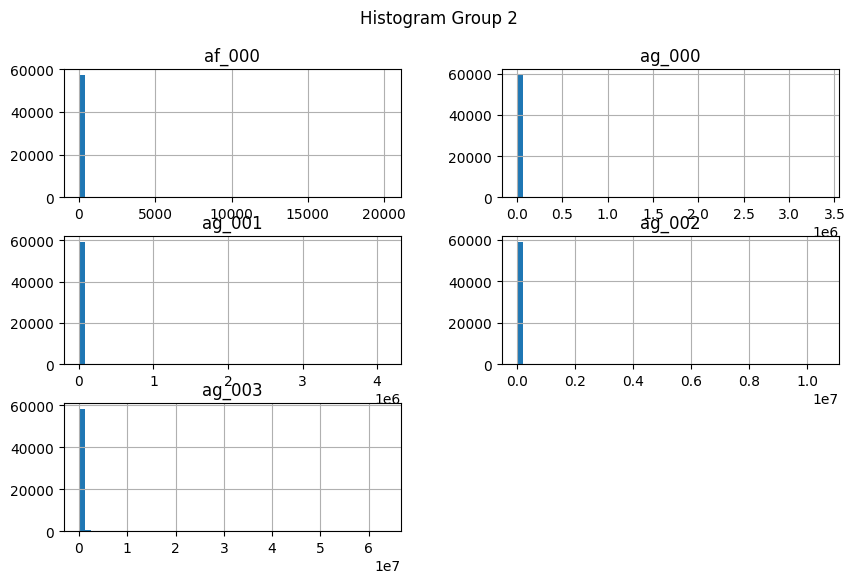

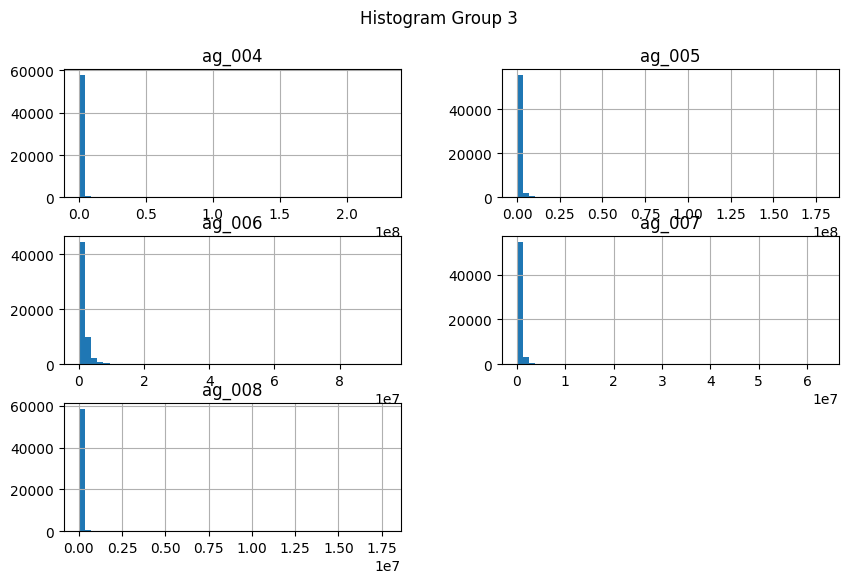

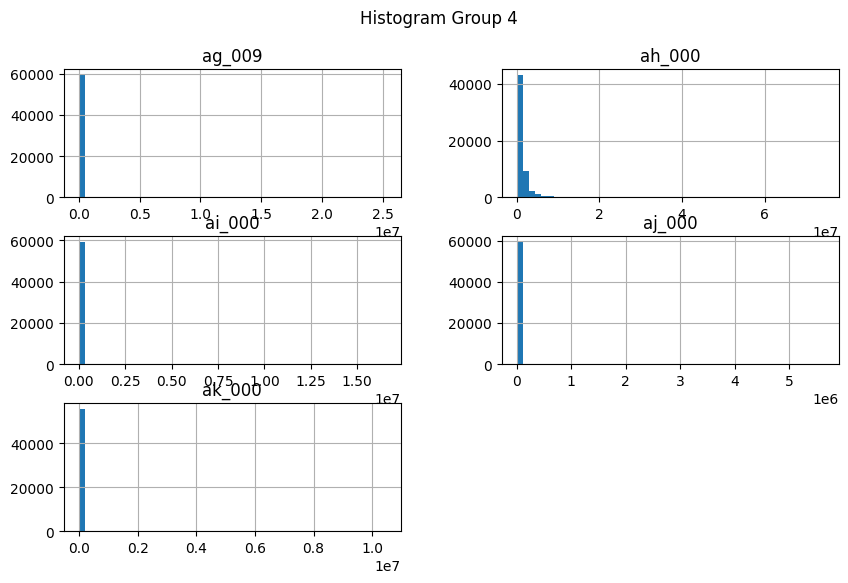

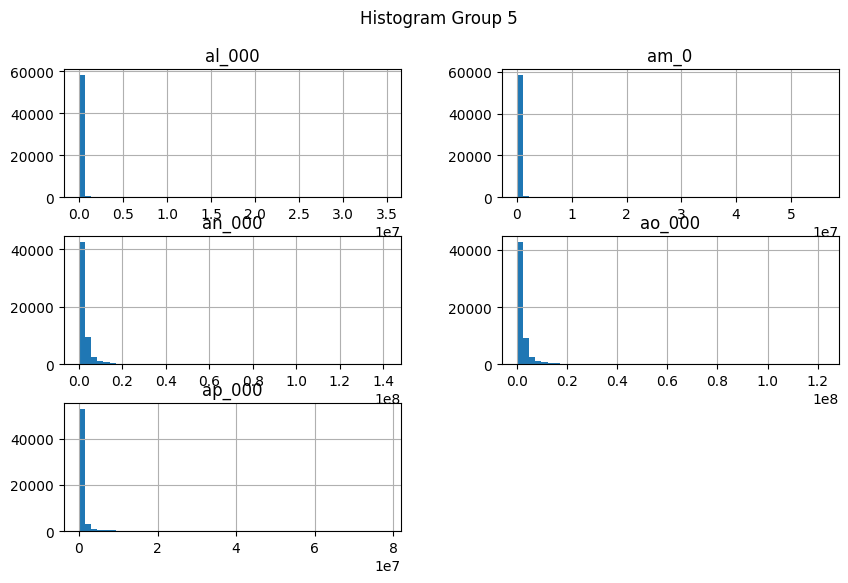

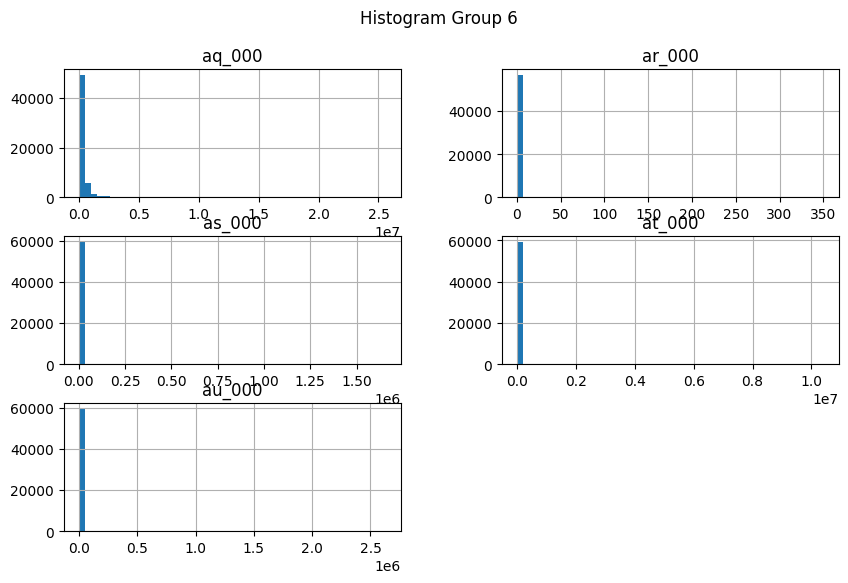

In [5]:
feature_cols = df_train.columns[1:]  

groups = [feature_cols[i:i+5] for i in range(0, len(feature_cols), 5)]

for i, group in enumerate(groups[:6]):
    df_train[group].hist(bins=50, figsize=(10,6))
    plt.suptitle(f"Histogram Group {i+1}")
    plt.show()

I created subsets of the features to get a better visualization. There were too many variables in the dataset and that caused issues with a normal histogram. This shows me that a lot of the features are skewed and are not normally distributed. Several of them have extreme values that indicate outliers. There is also a significant variance in the scale of the features.

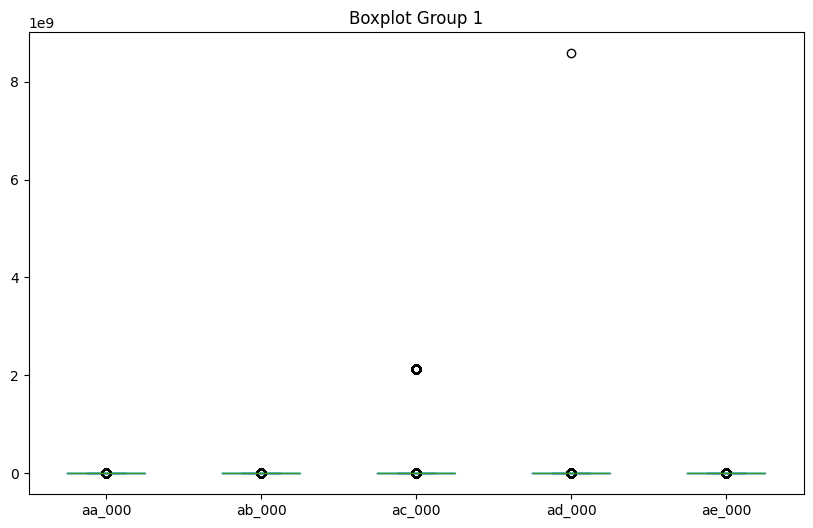

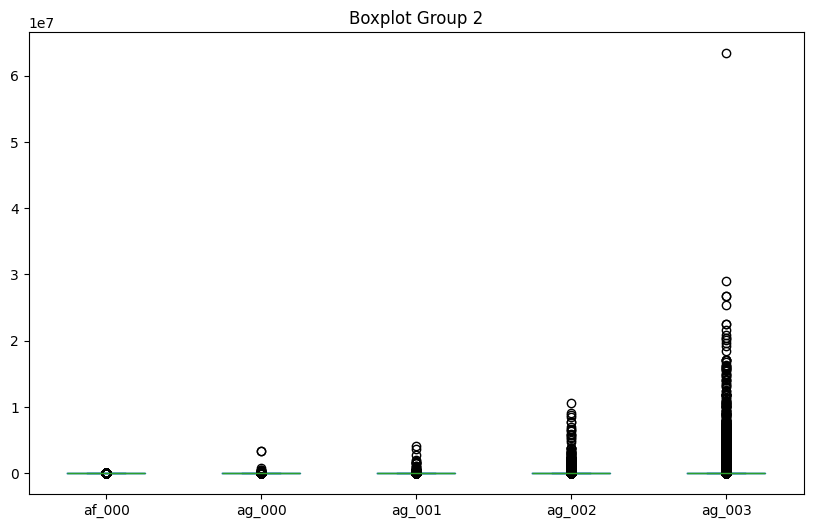

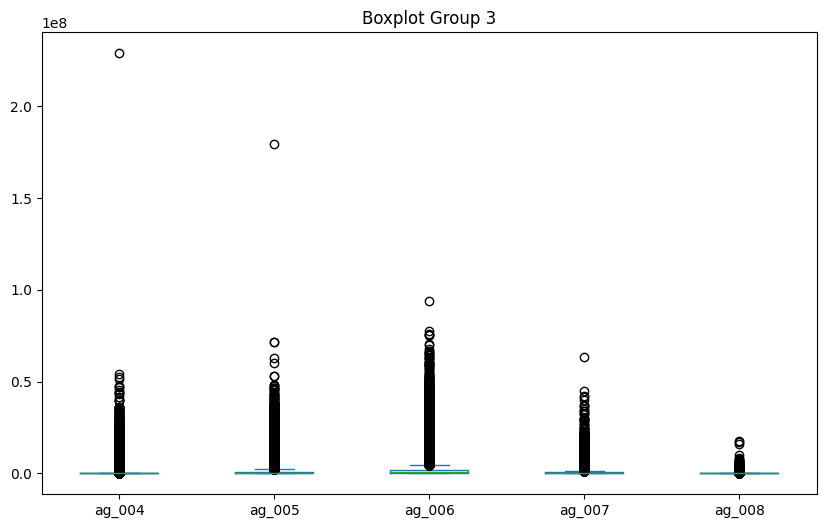

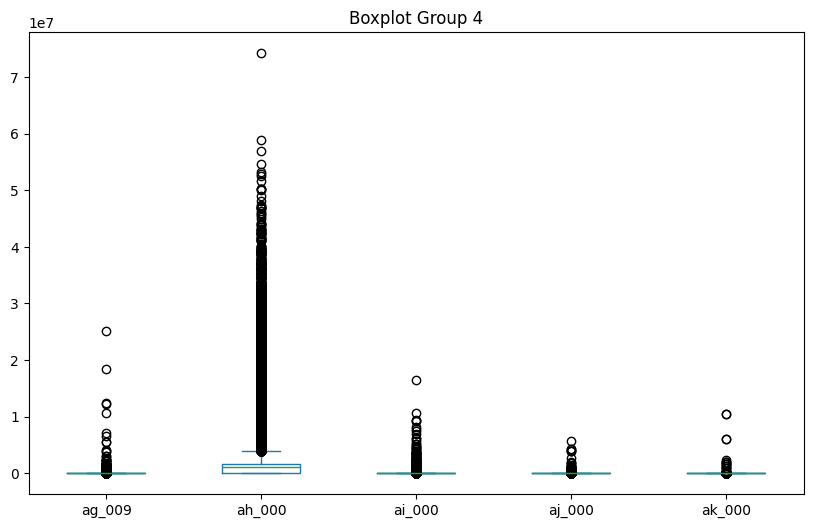

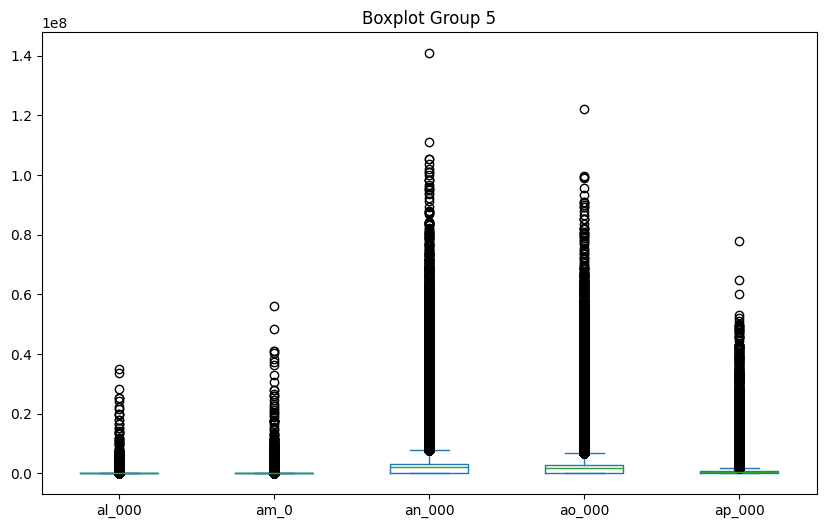

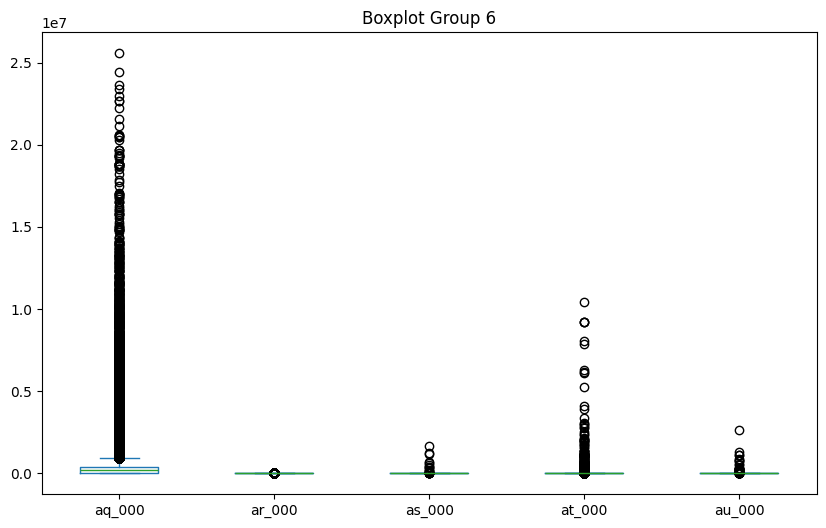

In [6]:
for i, group in enumerate(groups[:6]):
    df_train[group].plot(kind='box', figsize=(10,6))
    plt.title(f"Boxplot Group {i+1}")
    plt.show()

The boxplots show that the grouped features have outliers across many of the variables. There are extremely large values that are compressing the smaller values so scaling might need to be implemented.

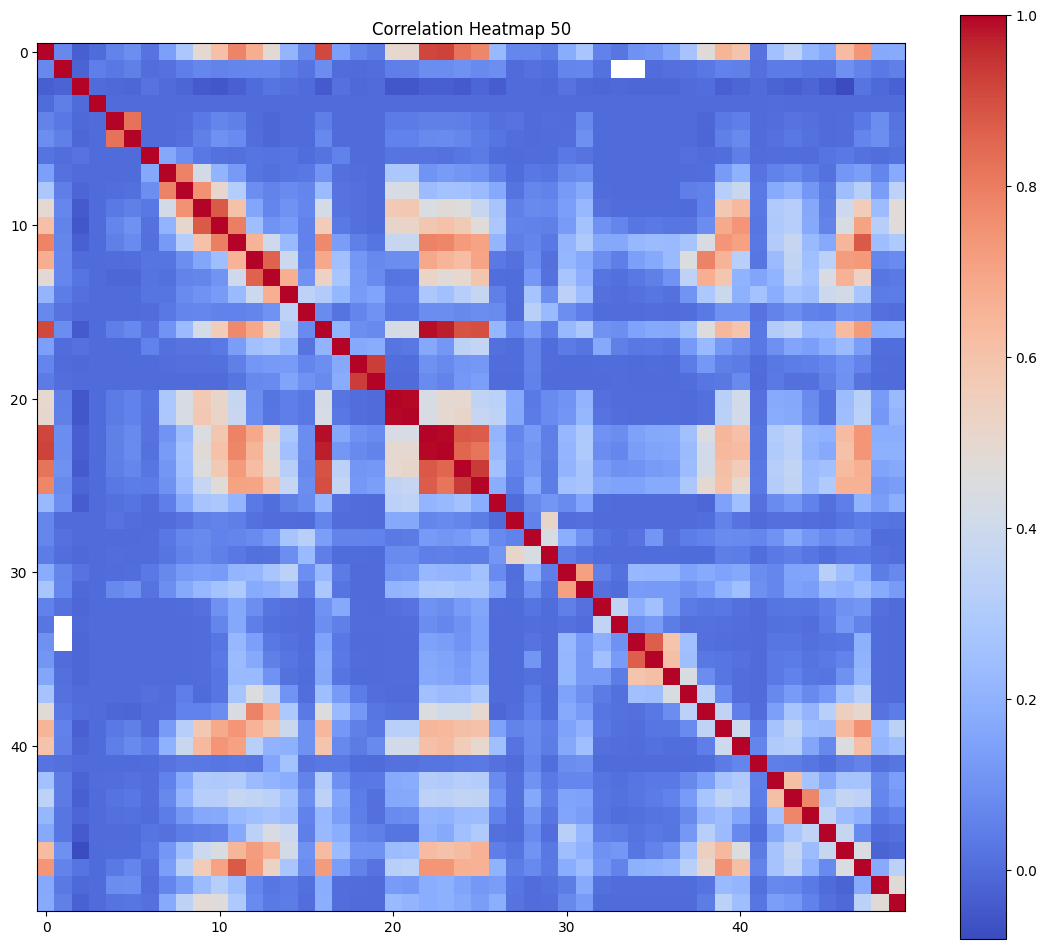

In [7]:
subset_corr = df_train.iloc[:, 1:51].corr()

plt.figure(figsize=(14,12))
plt.imshow(subset_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title("Correlation Heatmap 50")
plt.show()

The heatmap shows clusters of moderately correlated variables in the 8 to 25 range and some less so in the 35-50 range. So the features share some similar data. It doesn't look like the features are strongly tied together.

The data is messy and needs preprocessing before the models are built. There needs to be correction of missing values, fixing the scale differences and addressing imbalances.
My key findings are:

--A large number of features contain missing values
--The dataset is highly imbalanced
--Many features are skewed and contain outliers
--Features vary significantly in scale
--Some features are moderately correlated, but most are not

# Data Preprocessing

In [8]:
missing_rates = df_train.isnull().mean()
cols_to_drop = missing_rates[missing_rates > 0.70].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >70% missing values")

df_train_clean = df_train.drop(columns=cols_to_drop)
df_test_clean  = df_test.drop(columns=cols_to_drop)

X_train = df_train_clean.drop('class', axis=1)
y_train = df_train_clean['class']
X_test  = df_test_clean.drop('class', axis=1)
y_test  = df_test_clean['class']

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

Dropping 7 columns with >70% missing values


Fixing the missing values is the priority since there are so many. Using a median value seems like a good choice due to the extreme difference in values that is observed. Im going to drop all columns with missing data above 70% and then use the imputer to fill the remaining.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

This will standardize the scaling so the model wont get biased by large values.

# Models

In [10]:
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

grid = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV F1 score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

best_log_reg = grid.best_estimator_
y_pred = best_log_reg.predict(X_test)

Best CV F1 score: 0.5566961314813501
Best parameters: {'C': 0.01}


In [11]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9762
Precision: 0.4958
Recall:    0.9360
F1 Score:  0.6482

Confusion Matrix:
[[15268   357]
 [   24   351]]


Logistic regression with class_weight='balanced' caught most of the failures with a recall of 0.94 and only 24 misses out of 375. The precision is bad though at around 0.50 which means about half of what it flags as a failure actually isnt. The class weighting is doing what it should but its also making the model trigger happy. Im not sure yet if thats acceptable or not since it depends on how much the false positives actually cost in this scenario.

In [12]:
param_grid = {
    'n_neighbors': [3, 5, 7, 11],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV F1 score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

Best CV F1 score: 0.692597742693938
Best parameters: {'n_neighbors': 3, 'weights': 'distance'}


In [13]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9884
Precision: 0.8682
Recall:    0.5973
F1 Score:  0.7077

Confusion Matrix:
[[15591    34]
 [  151   224]]


knn ended up going the other direction. Without a class_weight option it leaned toward the majority class which is what the imbalance pulls it toward. Precision jumped up but recall dropped to 0.60 and it missed 151 failures. The best params landed on 3 neighbors with distance weighting which makes sense given how spread out the features are. This makes me think the distance based models are going to struggle on this dataset since there are so many negatives crowding the positives.

In [14]:
param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 10, 30]
}

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV F1 score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

best_dt = grid.best_estimator_
y_pred = best_dt.predict(X_test)

Best CV F1 score: 0.6071280759680648
Best parameters: {'max_depth': None, 'min_samples_split': 2}


In [15]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9860
Precision: 0.7459
Recall:    0.6107
F1 Score:  0.6716

Confusion Matrix:
[[15547    78]
 [  146   229]]


The decision tree picked max_depth=None which means it could keep splitting until the leaves were pure. That creates a higher risk of overfitting because the tree can become too specific to the training data. Even with class_weight='balanced' the tree missed 146 failures. So this model was not a good fit for catching the rare APS failures.

In [16]:
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42, dual=False)

grid = GridSearchCV(
    svc,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV F1 score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

best_svc = grid.best_estimator_
y_pred = best_svc.predict(X_test)

Best CV F1 score: 0.5486722028579692
Best parameters: {'C': 0.01}


In [17]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9764
Precision: 0.4986
Recall:    0.9333
F1 Score:  0.6500

Confusion Matrix:
[[15273   352]
 [   25   350]]


linear svm ended up almost the same as logistic regression which actually makes sense. Both are linear models with class weighting so theyre going to find similar decision boundaries. The training time was way longer though, about 14 minutes which I wasnt expecting. If both linear models give the same result Id probably just stick with logistic regression since its faster.

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV F1 score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

Best CV F1 score: 0.7025184002318337
Best parameters: {'max_depth': None, 'n_estimators': 100}


In [19]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9892
Precision: 0.9471
Recall:    0.5733
F1 Score:  0.7143

Confusion Matrix:
[[15613    12]
 [  160   215]]


random forest had the best precision so far at 0.95 with only 12 false positives. The problem is recall dropped to 0.57 and it missed 160 failures. So even though it sounds good on paper the model is being too conservative. I think whats happening is that the random forest averages the votes across trees and the minority class signal gets washed out even with class weighting. Boosting might handle this better since each tree is supposed to fix the previous ones errors.

In [20]:

scale = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.1, 0.3]
}

xgb = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV F1 score:", grid.best_score_)
print("Best parameters:", grid.best_params_)

best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(X_test)

Best CV F1 score: 0.8263516742159729
Best parameters: {'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 200}


In [21]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9949
Precision: 0.9349
Recall:    0.8427
F1 Score:  0.8864

Confusion Matrix:
[[15603    22]
 [   59   316]]


xgboost is way better than everything else by the normal classification metrics. F1 was 0.89, with only 22 false positives and 59 false negatives. It used scale_pos_weight instead of class_weight since xgboost doesnt support class_weight directly. What I think is happening is the boosting iteratively focuses on the mistakes so it doesnt let the positive class get washed out the way the averaging seems to in random forest. At this point xgboost looks like the best balanced model, but I still need to check the official Scania cost metric before calling it the best overall choice.

# Results

In [22]:
models = {
    'Logistic Regression': best_log_reg,
    'KNN': best_knn,
    'Decision Tree': best_dt,
    'Linear SVM': best_svc,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

result_rows = []
train_test_rows = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    scania_cost = 10 * fp + 500 * fn

    result_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1': f1_score(y_test, y_test_pred),
        'FN': fn,
        'FP': fp,
        'Scania Cost': scania_cost
    })

    train_test_rows.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train Precision': precision_score(y_train, y_train_pred),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Train Recall': recall_score(y_train, y_train_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred)
    })

results = pd.DataFrame(result_rows)
train_test_results = pd.DataFrame(train_test_rows)

score_cols = ['Accuracy', 'Precision', 'Recall', 'F1']
train_test_score_cols = [
    'Train Accuracy', 'Test Accuracy',
    'Train Precision', 'Test Precision',
    'Train Recall', 'Test Recall',
    'Train F1', 'Test F1'
]

results[score_cols] = results[score_cols].round(4)
train_test_results[train_test_score_cols] = train_test_results[train_test_score_cols].round(4)

results

,Model,Accuracy,Precision,Recall,F1,FN,FP,Scania Cost
0,Logistic Regression,0.9762,0.4958,0.9360,0.6482,24,357,15570
1,KNN,0.9884,0.8682,0.5973,0.7077,151,34,75840
2,Decision Tree,0.9860,0.7459,0.6107,0.6716,146,78,73780
3,Linear SVM,0.9764,0.4986,0.9333,0.6500,25,352,16020
4,Random Forest,0.9892,0.9471,0.5733,0.7143,160,12,80120
5,XGBoost,0.9949,0.9349,0.8427,0.8864,59,22,29720


Putting all the final test metrics into a single dataframe is simpler to compare. I also added the official Scania cost.

In [23]:
train_test_results

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,Logistic Regression,0.9763,0.9762,0.4090,0.4958,0.948,0.9360,0.5714,0.6482
1,KNN,1.0000,0.9884,1.0000,0.8682,1.000,0.5973,1.0000,0.7077
2,Decision Tree,1.0000,0.9860,1.0000,0.7459,1.000,0.6107,1.0000,0.6716
3,Linear SVM,0.9760,0.9764,0.4061,0.4986,0.949,0.9333,0.5688,0.6500
4,Random Forest,1.0000,0.9892,1.0000,0.9471,0.999,0.5733,0.9995,0.7143
5,XGBoost,1.0000,0.9949,1.0000,0.9349,1.000,0.8427,1.0000,0.8864


 This table is mainly an overfitting check. If a model does way better on the training set than the test set, then it probably learned the training data too closely and did not generalize as well.

In [24]:
overfit_check = train_test_results[['Model', 'Train Recall', 'Test Recall', 'Train F1', 'Test F1']].copy()
overfit_check

,Model,Train Recall,Test Recall,Train F1,Test F1
0,Logistic Regression,0.948,0.9360,0.5714,0.6482
1,KNN,1.000,0.5973,1.0000,0.7077
2,Decision Tree,1.000,0.6107,1.0000,0.6716
3,Linear SVM,0.949,0.9333,0.5688,0.6500
4,Random Forest,0.999,0.5733,0.9995,0.7143
5,XGBoost,1.000,0.8427,1.0000,0.8864


This smaller table is easier to use in the report. Recall and F1 are the main ones I care about because the positive class is rare and missed APS failures matter more than just overall accuracy.

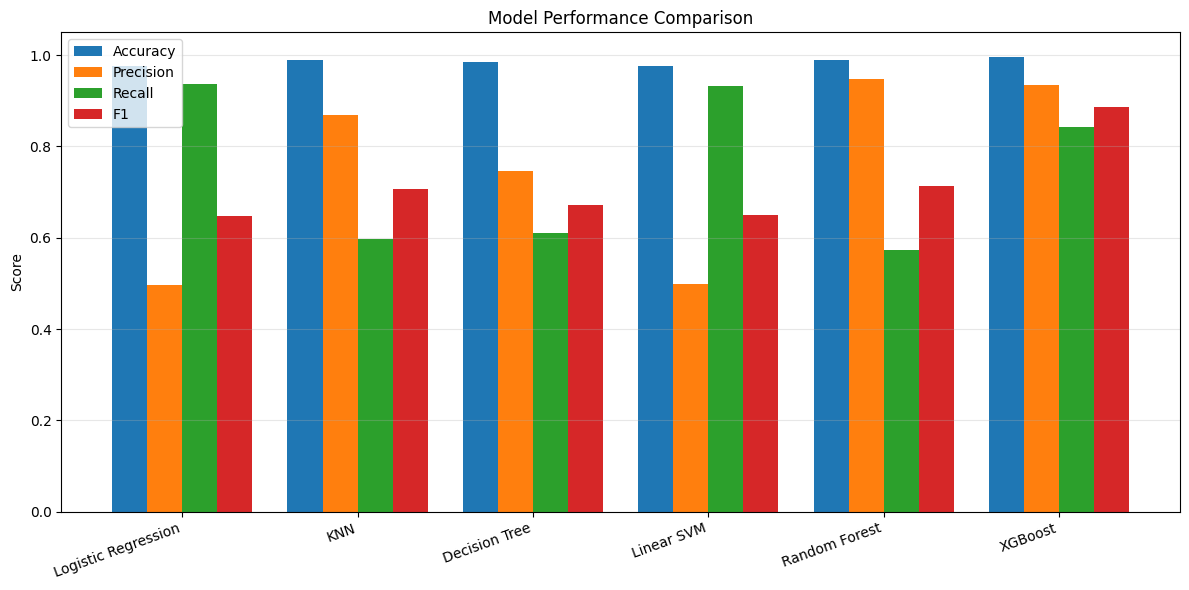

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results))
width = 0.2

ax.bar(x - 1.5*width, results['Accuracy'],  width, label='Accuracy')
ax.bar(x - 0.5*width, results['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, results['Recall'],    width, label='Recall')
ax.bar(x + 1.5*width, results['F1'],        width, label='F1')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


The bar chart makes the precision recall tradeoff really obvious. Logistic regression and linear svm both have super high recall but their precision is way down. knn, decision tree, and random forest are flipped. xgboost is the only one thats high on both.

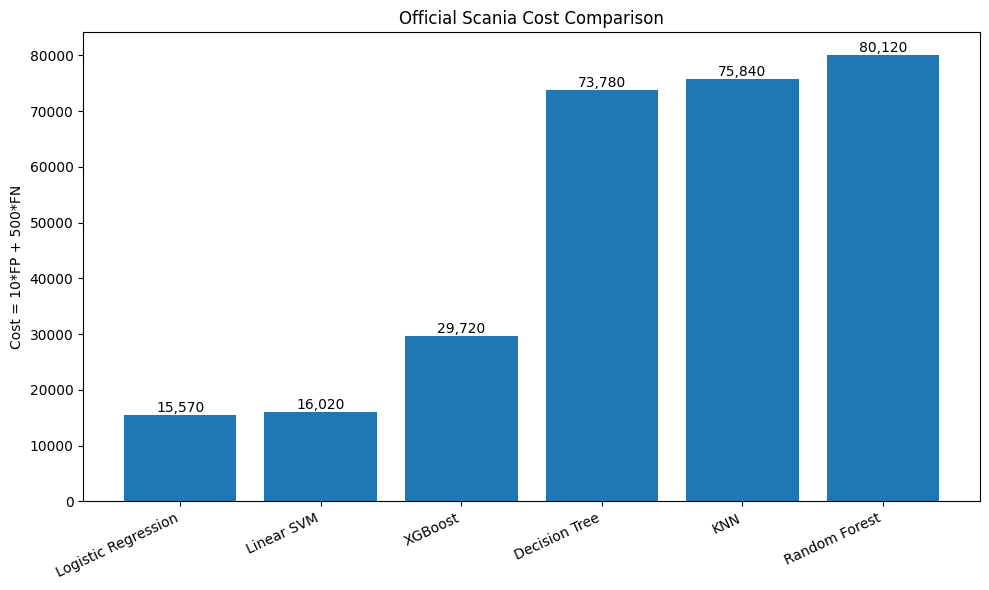

In [26]:
cost_results = results.sort_values('Scania Cost')

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cost_results['Model'], cost_results['Scania Cost'])
ax.set_ylabel('Cost = 10*FP + 500*FN')
ax.set_title('Official Scania Cost Comparison')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

for i, value in enumerate(cost_results['Scania Cost']):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

The cost chart changes the way the results look. xgboost still has the best F1 score, but logistic regression has the lowest official cost because it missed fewer real APS failures. Since a false negative costs 500 and a false positive costs 10, the model with fewer missed failures can be better even if it has more false alarms.

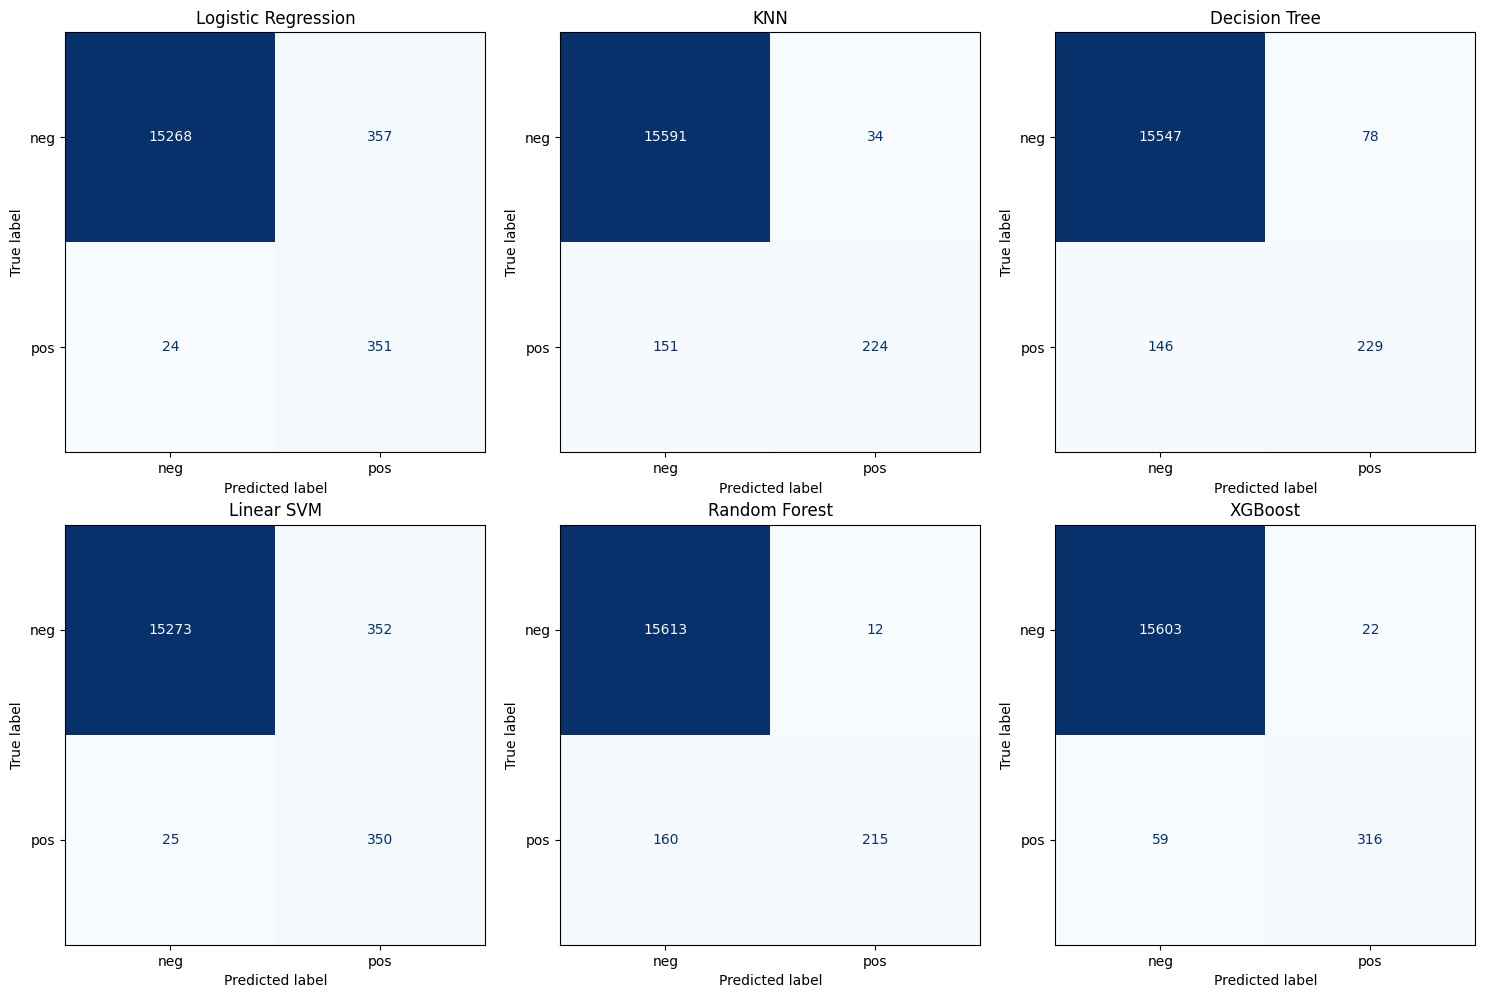

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred_m = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_m)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neg', 'pos'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Looking at all six confusion matrices side by side I can see two patterns. The linear models catch almost every failure but flag a ton of good tucks. knn and the tree models do the opposite, they barely flag anything but miss a lot of real failures. xgboost has the best balance with 22 false positives and 59 false negatives. The visual comparison is much clearer than reading the numbers.

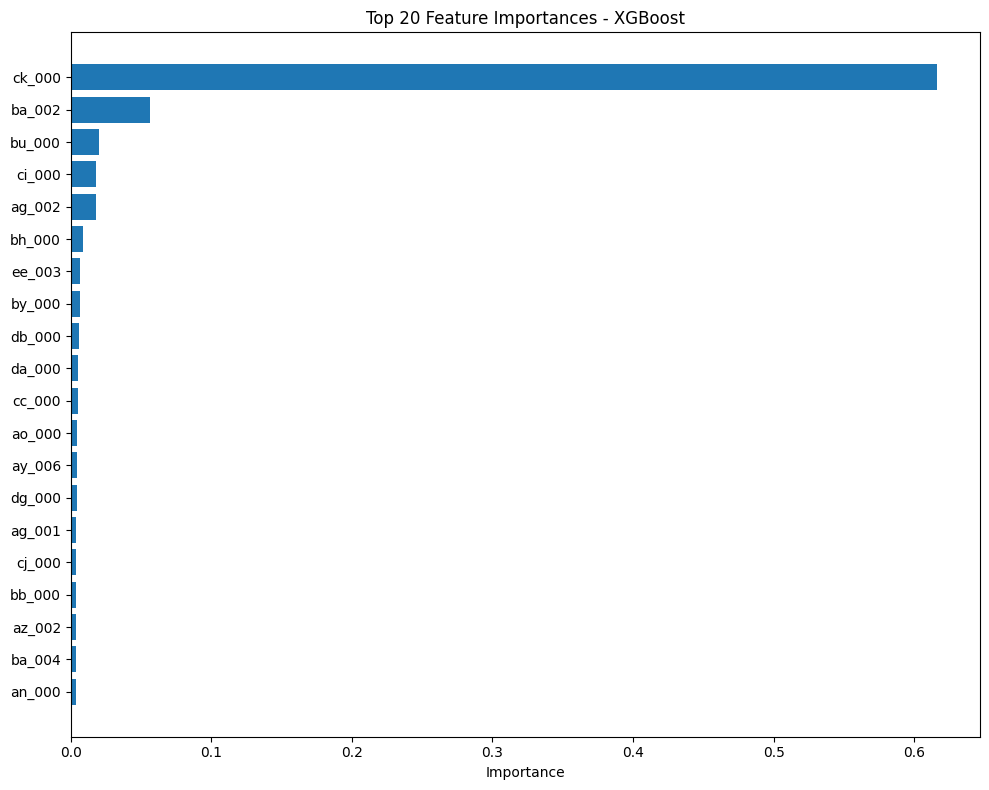

In [28]:
feature_names = df_train_clean.drop('class', axis=1).columns

importances = best_xgb.feature_importances_

feat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_importance['feature'][::-1], feat_importance['importance'][::-1])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances - XGBoost')
plt.tight_layout()
plt.show()

Looking at the feature importance plot for xgboost, ck_000 is doing about 62% of the work all by itself. ba_002 is in second place at around 6% and the rest are pretty small. Since the features are anonymized I dont actually know what ck_000 measures but its clearly the strongest signal in the dataset. If I had knowledge of which sensor that maps to it would probably tell me a lot about why APS failures happen.

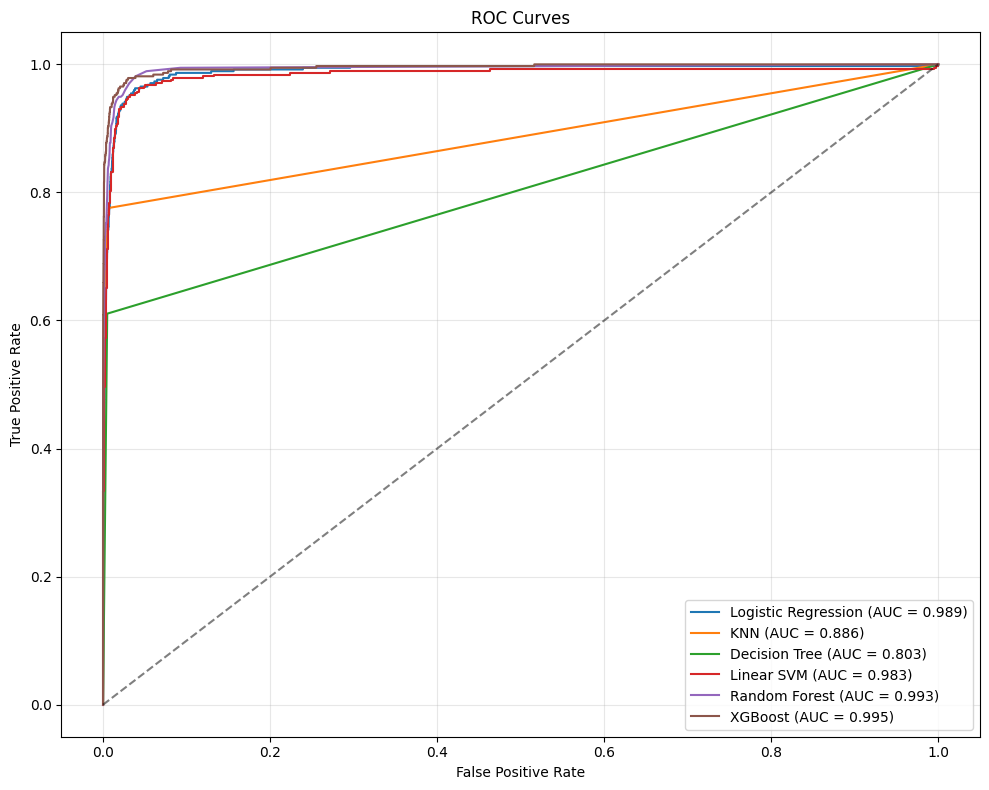

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")


ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The ROC curves confirm what the other plots showed. xgboost has the best AUC at 0.995 and random forest is right behind at 0.993. Logistic regression and linear svm are still strong at around 0.98. knn and the decision tree have those weird straight line shapes because they only output a few different probability values, not smooth ones. The top four models are all really close in AUC which means with threshold tuning even the linear models could potentially do well.

# Conclusion

xgboost was the best model by the normal model metrics. It had an F1 of 0.89, accuracy of 0.99, and AUC of 0.995. It only had 22 false positives and missed 59 failures, so by F1 and AUC it was the strongest balanced model.

The cost metric changed how I had to think about the final answer though. Logistic regression and linear svm caught most of the failures because of class_weight='balanced'. They had a lot of false positives, around 350 each, but logistic regression only missed 24 failures and linear svm only missed 25. Since the official Scania cost metric makes false negatives 50 times more expensive than false positives, logistic regression had the lowest total cost.

The main thing I took from this is that the class imbalance had a big effect on the results. If I only look at F1 and AUC, xgboost is the best answer. If I look at the official cost metric, logistic regression is the better operational choice. A better next step would be tuning the classification threshold directly against the Scania cost metric instead of tuning everything with F1 first and calculating cost afterward.